<a href="https://colab.research.google.com/github/Alimusy/OIBSIP/blob/main/Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
iris = load_iris()
X = iris.data              # Features (measurements)
y = iris.target            # Labels (species numbers 0,1,2)
target_names = iris.target_names  # Species names


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=200)

In [51]:
y_pred = model.predict(X_test_scaled)

print("✅ MODEL PERFORMANCE REPORT\n")
print(classification_report(y_test, y_pred, target_names=target_names))


✅ MODEL PERFORMANCE REPORT

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


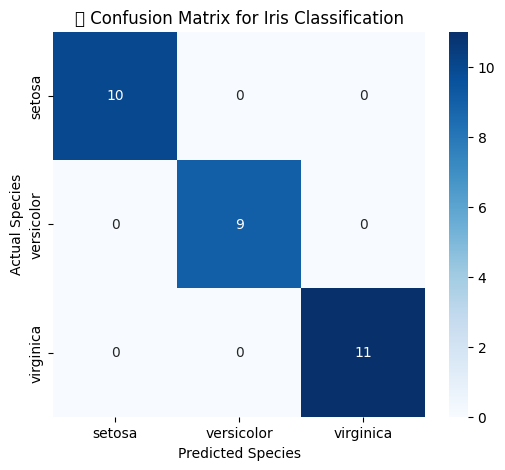

In [52]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('🌸 Confusion Matrix for Iris Classification')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.show()

In [56]:
print("\n🌸 IRIS FLOWER SPECIES PREDICTION 🌸")
sepal_length = float(input("Enter Sepal length (cm): "))
sepal_width = float(input("Enter Sepal width (cm): "))
petal_length = float(input("Enter Petal length (cm): "))
petal_width = float(input("Enter Petal width (cm): "))

user_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
user_data_scaled = scaler.transform(user_data)

prediction = model.predict(user_data_scaled)
predicted_species = target_names[prediction[0]]

print(f"\nPredicted Species: 🌼 {predicted_species.upper()}")


🌸 IRIS FLOWER SPECIES PREDICTION 🌸
Enter Sepal length (cm): 3
Enter Sepal width (cm): 4
Enter Petal length (cm): 2
Enter Petal width (cm): 0.4

Predicted Species: 🌼 SETOSA
